# NB2 — Dữ liệu sở thích (preference) tiếng Việt

**Bộ dữ liệu mặc định:** `sailor2/sea-ultrafeedback-onpolicy`, lọc `language == "Vietnamese"`
(khoảng 4.1k cặp). Lab cũ huấn luyện DPO trên UltraFeedback tiếng Anh trong khi SFT và
đánh giá đều bằng tiếng Việt, nên khó đọc hiệu ứng của DPO.

> **Mục tiêu:** đưa dữ liệu về dạng hội thoại của TRL
> (`prompt`/`chosen`/`rejected` là list message), lọc cặp vượt `MAX_LEN`,
> chia **tập huấn luyện/eval không trùng câu hỏi**, đo thiên vị độ dài, lưu Parquet.
>
> **Giấy phép:** bộ dữ liệu không ghi giấy phép. Nguồn gốc là UltraFeedback (câu hỏi) và
> phản hồi do mô hình sinh rồi được chấm, nên chỉ dùng cho học tập và nghiên cứu.
> Đặt `PREF_DATASET=argilla/ultrafeedback-binarized-preferences-cleaned PREF_LANGUAGE=`
> để chạy lại bản tiếng Anh làm đối chứng.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "lab22" / "config.py").exists())
sys.path.insert(0, str(ROOT))

from transformers import AutoTokenizer

from lab22 import config as C
from lab22 import data as D

C.ensure_dirs()
print(C.summary())

# Only the tokenizer is needed here: chat template + length budget. No GPU.
tokenizer = AutoTokenizer.from_pretrained(C.BASE_MODEL)

COMPUTE_TIER=T4 base=unsloth/Qwen3-4B-Instruct-2507-unsloth-bnb-4bit max_len=768 seed=42
SFT saillab/alpaca-vietnamese-cleaned[:1000]  PREF sailor2/sea-ultrafeedback-onpolicy (Vietnamese) train=800 eval=100
DPO beta=0.1 lr=5e-06 epochs=1.0 loss=['sigmoid']


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


## 1. Nạp, lọc, chia huấn luyện/eval theo câu hỏi

In [2]:
train_ds, eval_ds = D.load_preference_pairs(
    C.PREF_DATASET,
    tokenizer,
    max_len=C.MAX_LEN,
    n_train=C.PREF_TRAIN,
    n_eval=C.PREF_EVAL,
    language=C.PREF_LANGUAGE or None,
    seed=C.SEED,
    template_kwargs=C.CHAT_TEMPLATE_KWARGS,
)
D.assert_disjoint(list(train_ds), list(eval_ds))
print(f"train={len(train_ds)}  eval={len(eval_ds)}  (no prompt overlap)")
print(train_ds[0])

README.md:   0%|          | 0.00/530 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  134MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/38327 [00:00<?, ? examples/s]

Filter:   0%|          | 0/38327 [00:00<?, ? examples/s]

train=800  eval=100  (no prompt overlap)
{'prompt': [{'content': 'Tạo 10 yêu cầu thay đổi.\n\n--- ví dụ ---\nTrước: Một cô gái cưỡi ngựa\nYêu cầu: Biến cô ấy thành cưỡi kỳ lân\nSau: Một cô gái cưỡi kỳ lân\n--- kết thúc ví dụ ---', 'role': 'user'}], 'chosen': [{'content': '**10 Yêu cầu Thay đổi:**\n\n1. **Trước:** Một thị trấn xưa với xe ngựa\n**Yêu cầu:** Biến phương tiện giao thông thành xe bay\n**Sau:** Một thị trấn cổ với xe bay lơ lửng\n\n2. **Trước:** Bữa trà chiều truyền thống trong một ngôi nhà nông thôn\n**Yêu cầu:** Thêm các yếu tố tương lai (robot phục vụ, đồ nội thất tự thích nghi)\n**Sau:** Bữa trà "cyber-chic" với công nghệ tiên tiến\n\n3. **Trước:** Một nhà thám hiểm trong rừng\n**Yêu cầu:** Trao cho anh ta khả năng giao tiếp với thực vật\n**Sau:** Nhà thám hiểm sinh thái giao tiếp với rừng rậm\n\n4. **Trước:** Cảnh bãi biển mùa hè cổ điển\n**Yêu cầu:** Thêm các cấu trúc bãi biển dưới nước đa dạng sinh học\n**Sau:** Bãi biển đầy năng lượng tự duy trì với rạn san hô tinh t

## 2. Thiên vị độ dài

Nếu phần lớn `chosen` dài hơn `rejected`, DPO có thể học "viết dài hơn" thay vì
"trả lời tốt hơn". Ghi con số này vào REFLECTION và so với độ dài đầu ra ở NB4.

In [3]:
def n_tokens(text: str) -> int:
    return len(tokenizer(text, add_special_tokens=False)["input_ids"])


stats = D.length_stats(list(train_ds), count=n_tokens)
print(f"chosen median {stats['chosen_median']:.0f} tok · rejected median {stats['rejected_median']:.0f} tok")
print(f"chosen longer in {stats['chosen_longer_frac']:.1%} of pairs")

chosen median 94 tok · rejected median 86 tok
chosen longer in 65.9% of pairs


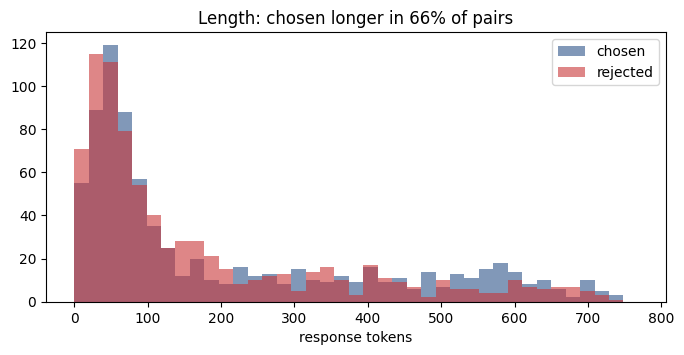

In [4]:
import matplotlib.pyplot as plt
import numpy as np

chosen = np.array([n_tokens(r["chosen"][0]["content"]) for r in train_ds])
rejected = np.array([n_tokens(r["rejected"][0]["content"]) for r in train_ds])
fig, ax = plt.subplots(figsize=(8, 3.5))
bins = np.linspace(0, C.MAX_LEN, 40)
ax.hist(chosen, bins=bins, alpha=0.6, label="chosen", color="#2e548a")
ax.hist(rejected, bins=bins, alpha=0.6, label="rejected", color="#c83538")
ax.set_xlabel("response tokens")
ax.set_title(f"Length: chosen longer in {stats['chosen_longer_frac']:.0%} of pairs")
ax.legend()
fig.savefig(C.SCREENSHOTS / "02b-pref-length.png", dpi=120, bbox_inches="tight")
plt.show()

## 3. Lưu

In [5]:
import json

train_ds.to_parquet(str(C.PREF_DIR / "train.parquet"))
eval_ds.to_parquet(str(C.PREF_DIR / "eval.parquet"))
(C.PREF_DIR / "stats.json").write_text(
    json.dumps({"dataset": C.PREF_DATASET, "language": C.PREF_LANGUAGE, **stats}, ensure_ascii=False, indent=2)
)
print(f"Saved {len(train_ds)} train / {len(eval_ds)} eval pairs → {C.PREF_DIR}")

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Saved 800 train / 100 eval pairs → /content/K4-L3-Track3-Day22-TaVanTuan-2A202602806-DPO-ORPO-Alignment/data/pref


## 4. Ghi chú vibe-coding

Mở 5 cặp ngẫu nhiên và tự chấm: bạn có đồng ý với nhãn `chosen` không? Khoảng 1%
câu `chosen` trong bộ này lẫn tiếng Anh hoặc mất dấu, một số câu hỏi là bài code.
Nếu bạn lọc thêm (ví dụ bỏ cặp lệch độ dài > 2×), ghi lại số cặp còn lại và lý do
vào REFLECTION. `BONUS-CHALLENGE.md` #1 gợi ý tự xây dữ liệu sở thích (preference) tiếng Việt gốc.

**Tiếp theo:** NB3 — huấn luyện DPO.